<a href="https://colab.research.google.com/github/ciril7/Elkanio-Internship/blob/main/Excercise%204/Diabetes_Prediction_using_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Diabetes Prediction using ANN(Artificial neutral network
)

Saving synthetic_diabetes_data.csv to synthetic_diabetes_data (2).csv
Dataset Shape: (1000, 8)

First 5 Rows:
         Age        BMI  BloodPressure  Cholesterol  Insulin    Glucose  \
0        NaN  19.031722          163.0        188.0    142.0        NaN   
1  65.074884  23.910795          147.0        286.0    262.0  137.61676   
2        NaN  18.488064           86.0        248.0     43.0  116.00000   
3        NaN  28.959634          133.0        226.0    216.0        NaN   
4  58.959118  28.476635           80.0        264.0     71.0        NaN   

   SkinThickness  Diabetes  
0           24.0       1.0  
1           12.0       1.0  
2           38.0       1.0  
3           15.0       1.0  
4           26.0       1.0  

Missing Values:
Age              100
BMI              100
BloodPressure    100
Cholesterol      100
Insulin          100
Glucose          100
SkinThickness    100
Diabetes         100
dtype: int64

Missing Values After Cleaning:
Age              0
BMI             

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9547 - loss: 0.4575 - val_accuracy: 0.9688 - val_loss: 0.3964
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9969 - loss: 0.3449 - val_accuracy: 0.9937 - val_loss: 0.2942
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.2525 - val_accuracy: 1.0000 - val_loss: 0.2118
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1796 - val_accuracy: 1.0000 - val_loss: 0.1494
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.1254 - val_accuracy: 1.0000 - val_loss: 0.1048
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0881 - val_accuracy: 1.0000 - val_loss: 0.0753
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0633 - val_accuracy: 1.0000 - val_loss: 0.0557
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0470 - val_accuracy: 1.0000 - val_loss: 0.0424
Epo

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


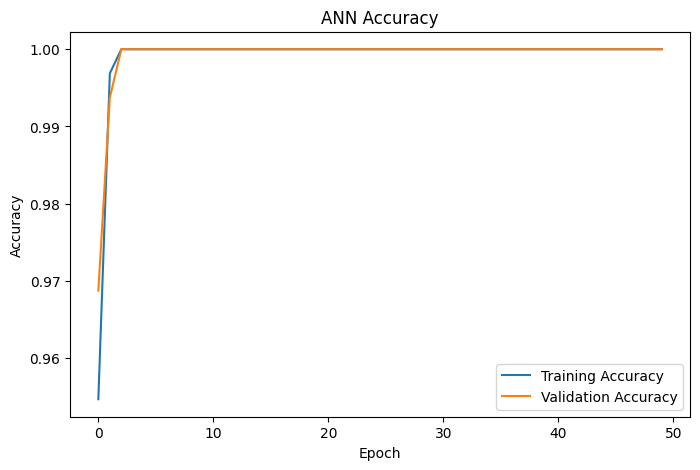

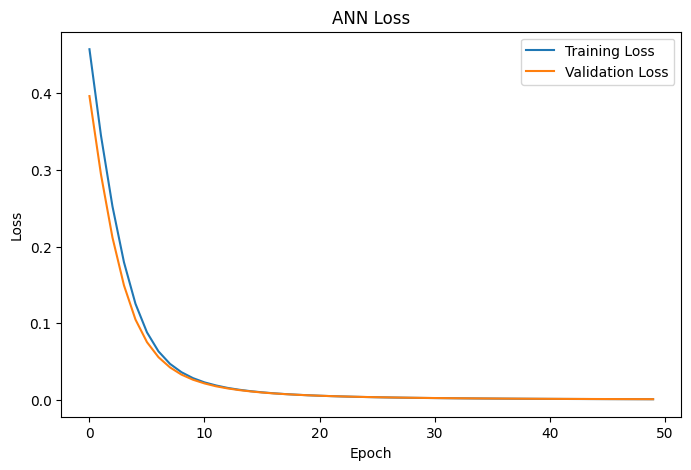


REPORT SUMMARY
1. Missing values handled using median imputation.
2. Data standardized before ANN training.
3. ANN built using TensorFlow/Keras.
4. Model evaluated using Accuracy, Confusion Matrix and Classification Report.
5. Training and validation curves plotted.


In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from google.colab import files

# Upload Dataset
uploaded = files.upload()

# Load Dataset
df = pd.read_csv('/content/synthetic_diabetes_data.csv')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# Handle Missing Values
# -----------------------------
imputer = SimpleImputer(strategy='median')

df[:] = imputer.fit_transform(df)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

# -----------------------------
# Features and Target
# -----------------------------
X = df.drop('Diabetes', axis=1)
y = (df['Diabetes'] > 0.5).astype(int) # Binarize the target variable

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# ANN Model
# -----------------------------
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Training
# -----------------------------
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# -----------------------------
# Prediction
# -----------------------------
pred_prob = model.predict(X_test)

pred = (pred_prob > 0.5).astype(int)

# -----------------------------
# Evaluation
# -----------------------------
accuracy = accuracy_score(y_test, pred)

print("\nAccuracy:", round(accuracy*100,2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

print("\nClassification Report:")
print(classification_report(y_test, pred))

# -----------------------------
# Accuracy Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'],
         label='Training Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# -----------------------------
# Loss Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'],
         label='Training Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title("ANN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# -----------------------------
# Report Summary
# -----------------------------
print("\nREPORT SUMMARY")
print("1. Missing values handled using median imputation.")
print("2. Data standardized before ANN training.")
print("3. ANN built using TensorFlow/Keras.")
print("4. Model evaluated using Accuracy, Confusion Matrix and Classification Report.")
print("5. Training and validation curves plotted.")